# Resume / Candidate Screening System
### Future Interns - Task 3

This notebook builds a machine learning system that screens, scores, and ranks candidate resumes against a given job description using NLP-based similarity matching, and identifies skill gaps for top candidates.

In [7]:
import pandas as pd

df = pd.read_csv("Resume.csv")
print(df.shape)
print(df["Category"].value_counts())
df.head()

(2484, 4)
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FINANCE                   118
FITNESS                   117
AVIATION                  117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


## Job Description Setup and Text Cleaning

A sample job description is defined for the target role (Information Technology). Both the resumes and the job description are cleaned using the same process — lowercasing, punctuation removal, and stopword removal — so they can be fairly compared later.

In [8]:
job_description = """
We are looking for an Information Technology professional with strong experience in
software development, system administration, and network management. The ideal
candidate should have hands-on experience with Python, SQL, Windows Server,
troubleshooting, technical support, cloud computing, cybersecurity, and project
management. Strong communication skills and the ability to work with cross-functional
teams are required.
"""

In [9]:
import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df["Cleaned_Resume"] = df["Resume_str"].apply(clean_text)
cleaned_job_description = clean_text(job_description)

df[["Resume_str", "Cleaned_Resume"]].head()

,Resume_str,Cleaned_Resume
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,hr administratormarketing associate hr adminis...
1,"HR SPECIALIST, US HR OPERATIONS ...",hr specialist us hr operations summary versati...
2,HR DIRECTOR Summary Over 2...,hr director summary years experience recruitin...
3,HR SPECIALIST Summary Dedica...,hr specialist summary dedicated driven dynamic...
4,HR MANAGER Skill Highlights ...,hr manager skill highlights hr skills hr depar...


## Resume-to-Job Similarity Scoring

Resumes and the job description are converted into TF-IDF vectors using a shared vocabulary. Cosine similarity is then calculated between each resume and the job description, producing a similarity score that ranks how closely each candidate's resume matches the role.

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

vectorizer = TfidfVectorizer(max_features=3000)
all_text = list(df["Cleaned_Resume"]) + [cleaned_job_description]
tfidf_matrix = vectorizer.fit_transform(all_text)

resume_vectors = tfidf_matrix[:-1]
job_vector = tfidf_matrix[-1]

similarity_scores = cosine_similarity(resume_vectors, job_vector).flatten()
df["Similarity_Score"] = similarity_scores

df[["ID", "Category", "Similarity_Score"]].sort_values(by="Similarity_Score", ascending=False).head(10)

,ID,Category,Similarity_Score
327,39413067,INFORMATION-TECHNOLOGY,0.327534
227,13836471,INFORMATION-TECHNOLOGY,0.309753
2399,27902692,AVIATION,0.294401
229,36434348,INFORMATION-TECHNOLOGY,0.293829
243,13385306,INFORMATION-TECHNOLOGY,0.293426
270,21283365,INFORMATION-TECHNOLOGY,0.275750
324,31243710,INFORMATION-TECHNOLOGY,0.274617
982,15145575,BPO,0.274584
314,10641230,INFORMATION-TECHNOLOGY,0.264534
1152,39441617,CONSULTANT,0.263712


## Skill Gap Identification

For each top-ranked candidate, we check which required skills for the role are present or missing in their resume text, helping recruiters quickly see where a candidate may need further screening or training.

In [11]:
required_skills = [
    "python", "sql", "windows server", "troubleshooting",
    "technical support", "cloud computing", "cybersecurity",
    "project management", "networking", "communication"
]

def find_missing_skills(resume_text, skills_list):
    missing = [skill for skill in skills_list if skill not in resume_text]
    return missing

df["Missing_Skills"] = df["Cleaned_Resume"].apply(lambda x: find_missing_skills(x, required_skills))

top_candidates = df.sort_values(by="Similarity_Score", ascending=False).head(10)
top_candidates[["ID", "Category", "Similarity_Score", "Missing_Skills"]]

,ID,Category,Similarity_Score,Missing_Skills
327,39413067,INFORMATION-TECHNOLOGY,0.327534,"[python, cloud computing, cybersecurity, netwo..."
227,13836471,INFORMATION-TECHNOLOGY,0.309753,"[python, troubleshooting, cloud computing, cyb..."
2399,27902692,AVIATION,0.294401,"[python, sql, technical support, cloud computi..."
229,36434348,INFORMATION-TECHNOLOGY,0.293829,"[python, technical support, cloud computing, c..."
243,13385306,INFORMATION-TECHNOLOGY,0.293426,"[python, windows server, troubleshooting, tech..."
270,21283365,INFORMATION-TECHNOLOGY,0.275750,"[python, sql, troubleshooting, cloud computing..."
324,31243710,INFORMATION-TECHNOLOGY,0.274617,"[python, technical support, cloud computing, c..."
982,15145575,BPO,0.274584,"[python, sql, cloud computing, cybersecurity, ..."
314,10641230,INFORMATION-TECHNOLOGY,0.264534,"[python, sql, technical support, cybersecurity..."
1152,39441617,CONSULTANT,0.263712,"[cloud computing, cybersecurity]"


## Visual Candidate Comparison

A bar chart visualizing the top 10 candidates by similarity score, making it easy to compare role fit across candidates at a glance.

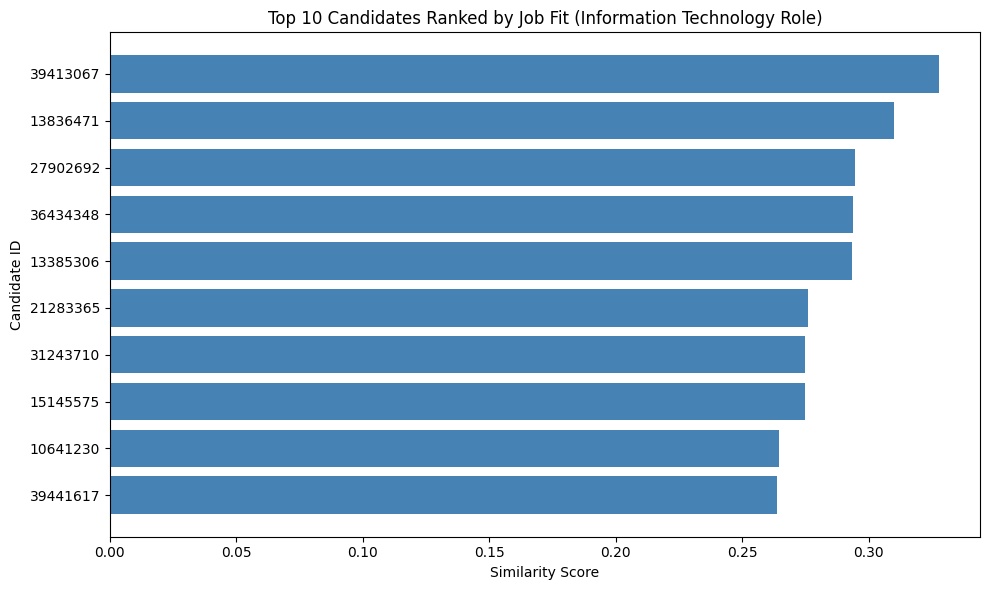

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(top_candidates["ID"].astype(str), top_candidates["Similarity_Score"], color="steelblue")
plt.xlabel("Similarity Score")
plt.ylabel("Candidate ID")
plt.title("Top 10 Candidates Ranked by Job Fit (Information Technology Role)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Business Insights & Evaluation Summary

**What we built:** A resume screening and ranking system that compares candidate resumes against a job description using TF-IDF vectorization and cosine similarity, then identifies missing skills for each top candidate.

**How scoring works:** Both the job description and every resume are converted into TF-IDF vectors — numerical representations that weigh words by how distinctive they are. Cosine similarity then measures how closely each resume's word usage aligns with the job description, producing a score between 0 and 1. Higher scores indicate stronger textual alignment with the role's requirements.

**Why certain candidates rank higher:** The top-ranked candidates in our results were overwhelmingly from the Information Technology category (7 of the top 10), confirming the scoring logic correctly identifies role-relevant resumes. A few resumes from adjacent categories (Aviation, BPO, Consultant) also scored highly, most likely due to shared vocabulary such as "systems," "technical," or "project management" — a realistic overlap that happens in real hiring too.

**What skills are missing:** Most top candidates were missing "python" specifically, even within the IT category. This is likely a keyword-matching limitation rather than a true skill gap — candidates may describe relevant experience using different terms (e.g., "scripting," "automation") or simply work in IT roles where Python isn't required (e.g., network administration, technical support).

**Limitation to be transparent about:** This system uses keyword and phrase-based text similarity, not true semantic understanding. It cannot infer skills described in different words, cannot verify skill proficiency, and treats all matched words with equal weight rather than prioritizing critical skills. A production system would benefit from more advanced techniques like named entity recognition for skill extraction, or semantic embeddings that understand meaning rather than exact word matches.

**Recommendation:** This system is a strong first-pass filter to reduce a large resume pool to a shortlist quickly, but final hiring decisions should always involve human review, especially given the keyword-matching limitations identified above.